# Experiment 4 -- aggregate and plot: comparison against published comparators

Reads every per-task CSV written by `run_experiment4.py` into
`Results_simulation/experiment4/raw/` (one file per `(regime, seed)`, each
with `5 methods x len(MU_GRID)` rows), aggregates the Monte Carlo mean and
standard error at each `(regime, mu, method)` grid point, writes the
combined table to `Results_simulation/experiment4/combined/`, and produces
the error-vs-alignment figure: one panel per regime (R1, R2, R3), target
misclustering error against `mu`, one line per method -- our target-only /
source-only / adaptive, plus the TGMM and TL-GMM comparators.

(A third comparator, Transfer Spectral Clustering, was considered and
dropped -- see the module docstring in `run_experiment4.py` for why its
co-clustering term is fundamentally mismatched with continuous Gaussian
data, not just numerically inconvenient.)

Run this after the SLURM array in `Slurm_Scripts/experiment4_comparators/`
has finished (or partially finished -- it works fine on a subset of seeds).

In [22]:
import sys, os, glob

# Hardcoded (rather than relative to "..") because the kernel's cwd isn't
# guaranteed to be this notebook's directory -- e.g. VS Code's Jupyter
# extension often starts kernels from the workspace root instead. Mirrors
# the PROJECT_ROOT convention already used in Slurm_Scripts/*/run_*.sh.
PROJECT_ROOT = "/home/nandy.15/Research/Transfer_clustering"
sys.path.insert(0, os.path.join(PROJECT_ROOT, "Experiments_Script"))

# The figure below uses matplotlib's text.usetex=True, which shells out to
# `latex`/`dvipng`. Hardcoded (rather than relying on `module load texlive`
# having been run in the launching shell) because the Jupyter kernel's PATH
# is whatever VS Code/Jupyter started with -- it won't see a module loaded
# after the fact. Matches the cluster's `module show texlive/2025`.
TEXLIVE_BIN = "/opt/lmod/texlive/2025/bin/x86_64-linux"
if TEXLIVE_BIN not in os.environ["PATH"].split(os.pathsep):
    os.environ["PATH"] = TEXLIVE_BIN + os.pathsep + os.environ["PATH"]

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from run_experiment4 import REGIME_ORDER, MU_GRID, REGIMES

In [23]:
RAW_DIR = os.path.join(PROJECT_ROOT, "Results_simulation", "experiment4", "raw")
COMBINED_DIR = os.path.join(PROJECT_ROOT, "Results_simulation", "experiment4", "combined")
os.makedirs(COMBINED_DIR, exist_ok=True)

paths = sorted(glob.glob(os.path.join(RAW_DIR, "*.csv")))
print(f"Found {len(paths)} raw result files")
assert paths, f"No CSVs found in {RAW_DIR} -- has the SLURM array finished any tasks yet?"

df = pd.concat([pd.read_csv(p) for p in paths], ignore_index=True)
df.head()

Found 300 raw result files


,regime,seed,mu,method,error,branch,C0_used,sigma_T2_hat,sigma_S2_hat
0,R1,0,0.0,target,0.485,NaN,NaN,0.994639,0.993551
1,R1,0,0.0,source,0.495,NaN,NaN,0.994639,0.993551
2,R1,0,0.0,adaptive,0.485,target,1.215206,0.994639,0.993551
3,R1,0,0.0,tgmm,0.480,NaN,NaN,0.994639,0.993551
4,R1,0,0.0,tlgmm,0.455,NaN,NaN,0.994639,0.993551


In [24]:
# Sanity check: how many distinct seeds actually landed per (regime, method)?
# If this is well short of N_SEEDS in run_experiment4.py, the array job
# hasn't finished (or some tasks failed -- check Slurm_Scripts/.../Error_Messages).
df.groupby(["regime", "method"])["seed"].nunique().unstack()

method,adaptive,source,target,tgmm,tlgmm
regime,,,,,
R1,100,100,100,100,100
R2,100,100,100,100,100
R3,100,100,100,100,100


In [25]:
summary = (
    df.groupby(["regime", "mu", "method"])["error"]
      .agg(mean_error="mean", se_error=lambda s: s.std(ddof=1) / np.sqrt(len(s)), n="count")
      .reset_index()
)
combined_path = os.path.join(COMBINED_DIR, "experiment4_summary.csv")
summary.to_csv(combined_path, index=False)
print(f"Wrote {combined_path}")
summary.head(15)

Wrote /home/nandy.15/Research/Transfer_clustering/Results_simulation/experiment4/combined/experiment4_summary.csv


,regime,mu,method,mean_error,se_error,n
0,R1,0.0,adaptive,0.47110,0.002156,100
1,R1,0.0,source,0.47005,0.002151,100
2,R1,0.0,target,0.46595,0.002353,100
3,R1,0.0,tgmm,0.47205,0.002212,100
4,R1,0.0,tlgmm,0.47055,0.002235,100
5,R1,0.1,adaptive,0.46835,0.002085,100
6,R1,0.1,source,0.46235,0.002651,100
7,R1,0.1,target,0.46595,0.002353,100
8,R1,0.1,tgmm,0.47165,0.002040,100
9,R1,0.1,tlgmm,0.47495,0.002016,100


## Figure: error versus alignment

One panel per regime (R1, R2, R3), `mu` on the x-axis, Monte Carlo mean
target misclustering error on a shared y-axis (so magnitudes are directly
comparable across regimes), one line per method with SE error bars. Colors
are fixed per method across all three panels (never reassigned): our three
methods first (blue/orange/green, matching Experiment 1's convention),
then the two comparators (magenta/red).

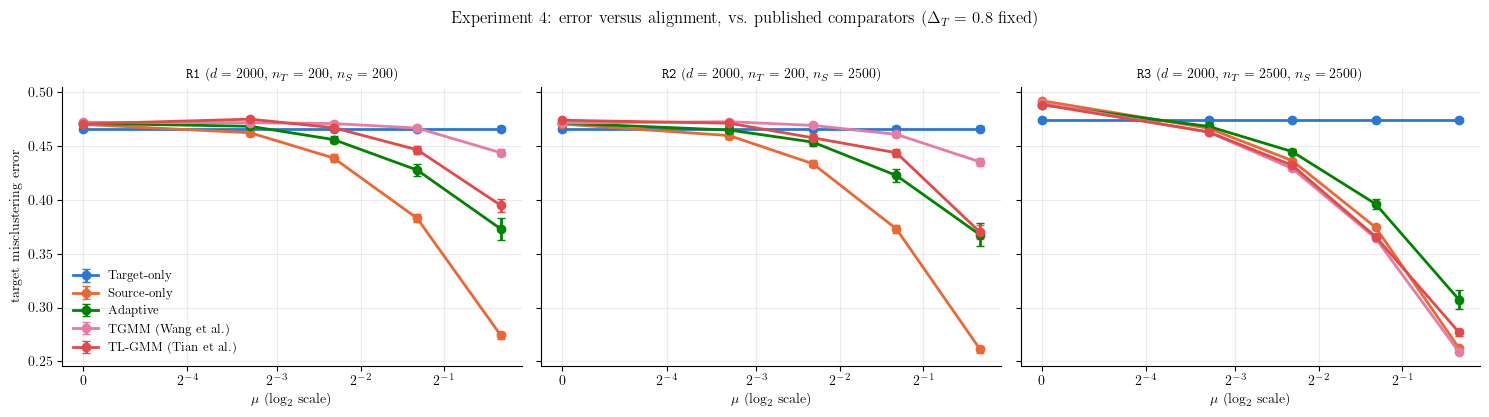

In [26]:
METHOD_COLORS = {
    "target": "#2a78d6",
    "source": "#eb6834",
    "adaptive": "#008300",
    "tgmm": "#e87ba4",
    "tlgmm": "#e34948",
}
METHOD_LABELS = {
    "target": "Target-only",
    "source": "Source-only",
    "adaptive": "Adaptive",
    "tgmm": "TGMM (Wang et al.)",
    "tlgmm": "TL-GMM (Tian et al.)",
}
METHOD_ORDER = ["target", "source", "adaptive", "tgmm", "tlgmm"]

# Smallest nonzero mu on the grid sets the linear-to-log crossover, so
# mu=0 still shows up (symlog can't take log of 0) while everything else
# is spaced by log2(mu).
LINTHRESH = min(mu for mu in MU_GRID if mu > 0)

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, regime in zip(axes, REGIME_ORDER):
    sub = summary[summary["regime"] == regime]
    for method in METHOD_ORDER:
        m = sub[sub["method"] == method].sort_values("mu")
        ax.errorbar(
            m["mu"], m["mean_error"], yerr=m["se_error"],
            label=METHOD_LABELS[method], color=METHOD_COLORS[method],
            linewidth=2, marker="o", markersize=6, capsize=3,
        )
    cfg = REGIMES[regime]
    ax.set_title(rf"\texttt{{{regime}}} ($d={cfg['d']}$, $n_T={cfg['n_T']}$, $n_S={cfg['n_S']}$)")
    ax.set_xscale("symlog", base=2, linthresh=LINTHRESH)
    ax.set_xlabel(r"$\mu$ (log$_2$ scale)")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(True, alpha=0.25)

axes[0].set_ylabel("target misclustering error")
axes[0].legend(frameon=False, fontsize=9)
fig.suptitle("Experiment 4: error versus alignment, vs. published comparators ($\\Delta_T = 0.8$ fixed)", y=1.03)
fig.tight_layout()
fig.savefig(os.path.join(COMBINED_DIR, "experiment4_error_vs_alignment.pdf"), bbox_inches="tight")
plt.show()

## Diagnostic: calibrated C0 stability (our adaptive method only)

`run_experiment4.py` also records `C0_used` for every `adaptive` row (the
bootstrap-calibrated constant from `calibrate_C0_bootstrap`, see
`Experiments_Script/transfer_clustering/two_community.py`). If it's roughly
stable within a regime (and across regimes, since it's meant to be a
universal constant), that supports caching a single calibrated `C0`
instead of re-bootstrapping per dataset.

In [27]:
c0 = df[df["method"] == "adaptive"].copy()
c0["C0_used"] = pd.to_numeric(c0["C0_used"], errors="coerce")
c0.groupby(["regime", "mu"])["C0_used"].agg(["mean", "std", "count"])

mean       std  count
regime mu                            
R1     0.0  1.209143  0.012394    100
       0.1  1.209143  0.012394    100
       0.2  1.209143  0.012394    100
       0.4  1.209143  0.012394    100
       0.8  1.209143  0.012394    100
R2     0.0  1.209143  0.012394    100
       0.1  1.209143  0.012394    100
       0.2  1.209143  0.012394    100
       0.4  1.209143  0.012394    100
       0.8  1.209143  0.012394    100
R3     0.0  1.029651  0.002093    100
       0.1  1.029651  0.002093    100
       0.2  1.029651  0.002093    100
       0.4  1.029651  0.002093    100
       0.8  1.029651  0.002093    100

## Diagnostic: estimated noise variances

`sigma_T2`/`sigma_S2` are NOT fixed to their true simulated values -- they
are estimated per repetition via `estimate_noise_variance_rank1` (the same
rank-1-residual estimator our own adaptive method already uses internally)
and the identical estimates are fed into all 5 methods. Since `X_T`
doesn't depend on `mu`, `sigma_T2_hat` should be essentially constant
across `mu` for a fixed `(regime, seed)`; `sigma_S2_hat` can vary with
`mu` since `X_S` is redrawn each time. Both should hover near the true
value of 1.0 used to generate the data, in every regime.

In [28]:
sigma_hats = df[df["method"] == "target"][["regime", "mu", "sigma_T2_hat", "sigma_S2_hat"]].copy()
sigma_hats[["sigma_T2_hat", "sigma_S2_hat"]] = sigma_hats[["sigma_T2_hat", "sigma_S2_hat"]].apply(pd.to_numeric, errors="coerce")
sigma_hats.groupby(["regime", "mu"])[["sigma_T2_hat", "sigma_S2_hat"]].agg(["mean", "std"])

sigma_T2_hat           sigma_S2_hat          
                   mean       std         mean       std
regime mu                                               
R1     0.0     0.991865  0.002508     0.994083  0.002022
       0.1     0.991865  0.002508     0.994525  0.002177
       0.2     0.991865  0.002508     0.994596  0.002222
       0.4     0.991865  0.002508     0.994251  0.002277
       0.8     0.991865  0.002508     0.994647  0.002015
R2     0.0     0.991865  0.002508     0.999018  0.000629
       0.1     0.991865  0.002508     0.998902  0.000585
       0.2     0.991865  0.002508     0.999028  0.000597
       0.4     0.991865  0.002508     0.999076  0.000589
       0.8     0.991865  0.002508     0.999240  0.000598
R3     0.0     0.998472  0.000604     0.998911  0.000630
       0.1     0.998472  0.000604     0.998998  0.000643
       0.2     0.998472  0.000604     0.999071  0.000585
       0.4     0.998472  0.000604     0.999230  0.000605
       0.8     0.998472  0.000604     0.999133  0.000698